# Experiment 1: Pipelined KV-Cache Attention

Compare the cost (cycles and energy) of KV-cache attention with and without pipelining.

Three workloads are evaluated against the TPU v4i architecture:
- **Baseline** (`gpt3_175B_kv_cache.yaml`): full context processed in one pass
- **2-chunk pipeline** (`gpt3_175B_kv_cache_pipeline2.yaml`): context split into 2 chunks, accumulated via vector unit
- **8-chunk pipeline** (`gpt3_175B_kv_cache_pipeline8.yaml`): context split into 8 chunks, accumulated via vector unit

Each workload is mapped automatically with AccelForge's mapper.

In [17]:
from accelforge import Spec, examples
from pathlib import Path

In [18]:
def get_cycles(result):
    return float(result.latency())

def get_energy(result):
    return float(result.energy())

def get_component_energy(result, component):
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

def get_component_cyles(result, component):
    latency = result.energy(per_component=True)
    return float(latency.get(component, 0))

## Baseline: Full KV-Cache (No Chunking)

In [10]:
# spec_baseline = Spec.from_yaml(
#     examples.arches.tpu_v4i,
#     "../workloads/gpt3_175B_kv_cache.yaml"
# )
# results_baseline = spec_baseline.map_workload_to_arch()

# cycles_baseline = get_cycles(results_baseline)
# energy_baseline = get_energy(results_baseline)
# print(f"Baseline  — cycles: {cycles_baseline:,.0f}  |  energy: {energy_baseline:,.0f} pJ")

Getting energy, latency, and leak power for components running FFB: 100%|███████████████| 10/10 [00:00<00:00, 15.10it/s]
Generating pmapping templates for compute ScalarUnit Einsum I: 2it [00:00, 71.06it/s]it/s]       | 0/10 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute MAC Einsum I: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 26it [00:00, 47.89it/s]
Generating pmapping templates for compute MAC Einsum QK_softmax: 0it [00:00, ?it

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V_new has 54 pmapping jobs:
	0	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in LocalBuffer] T-e  T-h  [V_new in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	1	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V_new in LocalBuffer] T-d  [I in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	2	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V_new in GlobalBuffer] T-d  S-Z-m  S-Z-h  S-Z

Compressing pmappings: 100%|████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 11.23it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████████████████████████| 340/340 [00:00<00:00, 911.21it/s]


...

Dirty joining uses 100.00% of the pmappings
Filtered 22611 -> 14095 (62.34% kept) pmappings


Final consolidate: 100%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 443.46it/s]
/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Dirty joining mapping(s) valid & optimal! Returning...


/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Baseline  — cycles: 0  |  energy: 0 pJ


## 2-Chunk Pipeline

In [11]:
spec_pipeline2 = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_kv_cache_pipeline2.yaml"
)
results_pipeline2 = spec_pipeline2.map_workload_to_arch()

cycles_pipeline2 = get_cycles(results_pipeline2)
energy_pipeline2 = get_energy(results_pipeline2)
print(f"2-chunk   — cycles: {cycles_pipeline2:,.0f}  |  energy: {energy_pipeline2:,.0f} pJ")

Getting energy, latency, and leak power for components running FFB: 100%|███████████████| 11/11 [00:00<00:00, 27.07it/s]
Generating pmapping templates for compute ScalarUnit Einsum I: 2it [00:00, 59.34it/s]:00, ?it/s] | 0/11 [00:00<?, ?it/s]
Generating pmapping templates for compute MAC Einsum I: 0it [00:00, ?it/s]0, ?it/s]it/s]
Generating pmapping templates for compute ScalarUnit Einsum K_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_chunk: 0it [00:00, ?it/s] | 1/11 [00:00<00:01,  8.06it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum FFB: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_chunk: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Z: 0it [00:00, ?it/s]
Generating pmapping templates for c

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V_new has 54 pmapping jobs:
	0	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in LocalBuffer] T-e  T-h  [V_new in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	1	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V_new in LocalBuffer] T-d  [I in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	2	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V_new in GlobalBuffer] T-d  S-Z-m  S-Z-h  S-Z

Compressing pmappings: 100%|████████████████████████████████████████████████████████████| 11/11 [00:02<00:00,  3.79it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|██████████████████████████████████████████████████████| 767/767 [00:00<00:00, 1308.89it/s]


...

Dirty joining uses 100.00% of the pmappings
Filtered 54578 -> 38517 (70.57% kept) pmappings


Grouping pmappings: 100%|██████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 373.05it/s]
Joining pmappings for QK_chunk <--> QK_softmax_chunk (6/11): 100%|███████████████████| 521/521 [00:01<00:00, 479.16it/s]
Grouping pmappings: 100%|██████████████████████████████████████████████████████████████| 65/65 [00:00<00:00, 222.52it/s]
Joining pmappings for QK_softmax_chunk <--> AV_chunk (7/11): 100%|███████████████████| 881/881 [00:03<00:00, 280.86it/s]
Final consolidate: 100%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 441.08it/s]
/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Dirty joining mapping(s) valid & optimal! Returning...


/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


2-chunk   — cycles: 0  |  energy: 0 pJ


## 8-Chunk Pipeline

In [12]:
spec_pipeline8 = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_kv_cache_pipeline8.yaml"
)
results_pipeline8 = spec_pipeline8.map_workload_to_arch()

cycles_pipeline8 = get_cycles(results_pipeline8)
energy_pipeline8 = get_energy(results_pipeline8)
print(f"8-chunk   — cycles: {cycles_pipeline8:,.0f}  |  energy: {energy_pipeline8:,.0f} pJ")

Getting energy, latency, and leak power for components running FFB: 100%|███████████████| 11/11 [00:00<00:00, 27.08it/s]
Generating pmapping templates for compute ScalarUnit Einsum I: 2it [00:00, 107.57it/s]s], ?it/s] | 0/11 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum K_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum V_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum FFB: 0it [00:00, ?it/s]

Generating pmapping templates for compute ScalarUnit Einsum AV_chunk: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Q_new: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_chunk: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum FFA: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Z: 0it [00:00, ?it/s]        | 1/11 [00:00<00:01,  8.79it/s]
Generating pmapping templates fo

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V_new has 54 pmapping jobs:
	0	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in LocalBuffer] T-e  T-h  [V_new in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	1	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V_new in LocalBuffer] T-d  [I in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V_new
	2	[WV in MainMemory] [V_new in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V_new in GlobalBuffer] T-d  S-Z-m  S-Z-h  S-Z

Compressing pmappings: 100%|████████████████████████████████████████████████████████████| 11/11 [00:03<00:00,  3.05it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████████████████████████| 701/701 [00:00<00:00, 848.69it/s]


...

Dirty joining uses 100.00% of the pmappings
Filtered 93389 -> 66966 (71.71% kept) pmappings


Grouping pmappings: 100%|██████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 219.47it/s]
Joining pmappings for QK_chunk <--> QK_softmax_chunk (6/11): 100%|███████████████████| 308/308 [00:01<00:00, 286.51it/s]
Grouping pmappings: 100%|██████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 113.18it/s]
Joining pmappings for QK_softmax_chunk <--> AV_chunk (7/11): 100%|███████████████████| 307/307 [00:00<00:00, 351.32it/s]
Final consolidate: 100%|███████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 398.60it/s]
/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

Dirty joining mapping(s) valid & optimal! Returning...


/mnt/c/Users/lyoko/Desktop/College/Grad/6.5931/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


8-chunk   — cycles: 0  |  energy: 0 pJ


## Per-Stage Cycle Breakdown

Cycles per einsum (pipeline stage) for each workload.
For the chunked workloads, the QK/SM/PV stages operate on one chunk at a time,
so divide their cycles by the number of chunks to get per-chunk cost.

In [13]:
import pandas as pd

def stage_breakdown(result, n_chunks=1):
    """Return a DataFrame of per-einsum cycles, plus per-chunk cost for chunked stages."""
    per_einsum = result.latency(per_einsum=True)
    rows = []
    for name, cycles in per_einsum.items():
        rows.append({
            "Stage": name,
            "Total cycles": cycles,
            "Per-chunk cycles": cycles / n_chunks,
            "Chunks": n_chunks,
        })
    return pd.DataFrame(rows).set_index("Stage")

print("=== Baseline (1 chunk) ===")
display(stage_breakdown(results_baseline, n_chunks=1))

print("\n=== 2-chunk pipeline ===")
display(stage_breakdown(results_pipeline2, n_chunks=2))

print("\n=== 8-chunk pipeline ===")
display(stage_breakdown(results_pipeline8, n_chunks=8))

=== Baseline (1 chunk) ===


,Total cycles,Per-chunk cycles,Chunks
Stage,,,
I,0.000002,0.000002,1
V_new,0.000062,0.000062,1
K_new,0.000062,0.000062,1
Q_new,0.000062,0.000062,1
QK,0.000062,0.000062,1
QK_softmax,0.000016,0.000016,1
AV,0.000062,0.000062,1
Z,0.000062,0.000062,1
FFA,0.000250,0.000250,1



=== 2-chunk pipeline ===


,Total cycles,Per-chunk cycles,Chunks
Stage,,,
I,0.000002,9.752381e-07,2
V_new,0.000062,3.120762e-05,2
K_new,0.000062,3.120762e-05,2
Q_new,0.000062,3.120762e-05,2
QK_chunk,0.000062,3.120762e-05,2
QK_softmax_chunk,0.000016,7.801905e-06,2
AV_chunk,0.000062,3.120762e-05,2
AV,0.000004,1.950476e-06,2
Z,0.000062,3.120762e-05,2



=== 8-chunk pipeline ===


,Total cycles,Per-chunk cycles,Chunks
Stage,,,
I,0.000002,2.438095e-07,8
V_new,0.000062,7.801905e-06,8
K_new,0.000062,7.801905e-06,8
Q_new,0.000062,7.801905e-06,8
QK_chunk,0.000062,7.801905e-06,8
QK_softmax_chunk,0.000016,1.950476e-06,8
AV_chunk,0.000062,7.801905e-06,8
AV,0.000016,1.950476e-06,8
Z,0.000062,7.801905e-06,8


## Summary Comparison

In [14]:
import pandas as pd

rows = [
    {"Workload": "Baseline (1 chunk)",  "Chunks": 1, "Cycles": cycles_baseline,  "Energy (pJ)": energy_baseline},
    {"Workload": "Pipeline (2 chunks)", "Chunks": 2, "Cycles": cycles_pipeline2, "Energy (pJ)": energy_pipeline2},
    {"Workload": "Pipeline (8 chunks)", "Chunks": 8, "Cycles": cycles_pipeline8, "Energy (pJ)": energy_pipeline8},
]
df = pd.DataFrame(rows).set_index("Workload")
df["Cycles (normalized)"] = df["Cycles"] / cycles_baseline
df["Energy (normalized)"] = df["Energy (pJ)"] / energy_baseline
df

,Chunks,Cycles,Energy (pJ),Cycles (normalized),Energy (normalized)
Workload,,,,,
Baseline (1 chunk),1,0.000891,0.004066,1.000000,1.000000
Pipeline (2 chunks),2,0.000895,0.004155,1.004376,1.021971
Pipeline (8 chunks),8,0.000907,0.004423,1.017505,1.087883


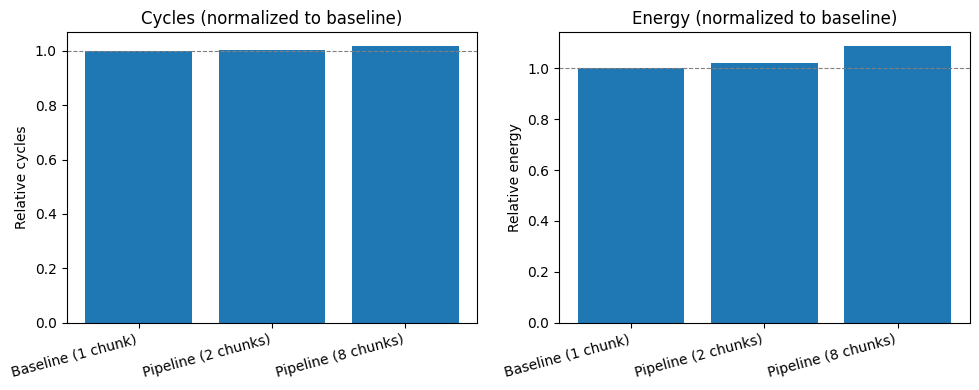

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

chunks = df["Chunks"]
ax1.bar(df.index, df["Cycles (normalized)"])
ax1.set_title("Cycles (normalized to baseline)")
ax1.set_ylabel("Relative cycles")
ax1.set_xticks(range(len(df)))
ax1.set_xticklabels(df.index, rotation=15, ha="right")
ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)

ax2.bar(df.index, df["Energy (normalized)"])
ax2.set_title("Energy (normalized to baseline)")
ax2.set_ylabel("Relative energy")
ax2.set_xticks(range(len(df)))
ax2.set_xticklabels(df.index, rotation=15, ha="right")
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()